# Overview - Data Cleaning & Preparation 

## Dataset Overview

| | Raw | After Data Cleaning | After NLP Preprocessing |
|---|---|---|---|
| **Posts** | 9302 | 9302 | 9215 |
| **Comments** | 38677 | 38677 | 38126|
| **Sources** | Arctic Shift API | — | — |

---

## Data Cleaning

Structural issues corrected on raw data. Applied separately to posts and comments.

### Posts
1. **Deduplication** by `id` — removed exact duplicates from overlapping API windows
2. **Missing title** — dropped rows where title was absent; selftext absence is *not* a removal criterion
3. **Selftext normalisation** — `[removed]`, `[deleted]`, `NaN` → empty string, preserving all subreddits
4. **Column reduction** — dropped `Unnamed*` artefacts, `author`, `url`
5. **Timestamp** — `created_utc` converted from Unix epoch to date
6. **Text cleaning** — URLs removed; kept letters, digits, and core sentiment punctuation `.,!?;:-'`; all other symbols stripped

### Comments
1. **Deduplication** by `id`
2. **Missing/removed body** — dropped rows with `NaN`, `[removed]`, `[deleted]`, or empty string
3. **Column reduction** — dropped `Unnamed*` artefacts, `author`, `parent_id`
4. **Timestamp** — same conversion as posts
5. **Text cleaning** — same regex as posts

---

## NLP Preprocessing

Content quality filtering and feature construction for downstream sentiment analysis.

| Action | Detail | Result |
|---|---|---|
| Remove short comments | `body_word_count < 3` (noise: "lol", "this", "agreed") | −597 comments |
| Deduplicate posts | Same `(title, subreddit)` → keep highest-score copy | −268 posts |
| Drop empty title/full_text | Titles stripped entirely by regex | −2 posts |
| Construct `full_text` | title + selftext (4,998 posts) or title only (4,165 posts) | NLP input field |
| Retain `word_count` features | `title_word_count`, `selftext_word_count`, `body_word_count` | NLP-ready variables |

---

## Final Dataset Schema

**Posts** — 9,161 rows × 10 columns

| Column | Type | Description |
|---|---|---|
| `created_utc` | date | Post date |
| `id` | str | Reddit post ID |
| `subreddit` | str | Source community |
| `title` | str | Cleaned post title |
| `selftext` | str | Cleaned post body (empty string if absent) |
| `full_text` | str | NLP input: title + selftext, or title alone |
| `score` | int | Net upvotes |
| `num_comments` | int | Comment count |
| `title_word_count` | int | Word count of title |
| `selftext_word_count` | int | Word count of selftext |

**Comments** — 40,151 rows × 7 columns

| Column | Type | Description |
|---|---|---|
| `created_utc` | date | Comment date |
| `id` | str | Reddit comment ID |
| `link_id` | str | Parent post ID |
| `subreddit` | str | Source community |
| `body` | str | Cleaned comment text |
| `score` | int | Net upvotes |
| `body_word_count` | int | Word count of comment |

---

## Coverage

**9 subreddits:** `artificial`, `careerguidance`, `cscareerquestions`, `datascience`, `Economics`, `Futurology`, `jobs`, `MachineLearning`, `technology`

**Time range:** January 2025 – December 2025

---

## Deliverables

| File | Rows | Columns | Description |
|---|---|---|---|
| `reddit_posts_clean.csv` | 9215| 10 | Final posts with `full_text` and `word_count` features |
| `reddit_comments_clean.csv` | 38126 | 7 | Final comments with `body_word_count` feature |


# Load Data

In [1]:
import pandas as pd
import os

DATA_DIR = r"c:\Users\13515\Downloads\ML_project\CleanNew"

# Load final cleaned data
posts    = pd.read_csv(os.path.join(DATA_DIR, "reddit_posts_2025_final.csv")).reset_index(drop=True)
comments = pd.read_csv(os.path.join(DATA_DIR, "reddit_comments_2025_final.csv")).reset_index(drop=True)

print(f"Loaded reddit_posts_2025_final.csv:    {posts.shape}")
print(f"Loaded reddit_comments_2025_final.csv: {comments.shape}")

Loaded reddit_posts_2025_final.csv:    (9302, 9)
Loaded reddit_comments_2025_final.csv: (38677, 8)


In [2]:
# Basic info on columns and data types before cleaning
posts.info()
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9302 entries, 0 to 9301
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   author        9302 non-null   object
 1   created_utc   9302 non-null   int64 
 2   id            9302 non-null   object
 3   num_comments  9302 non-null   int64 
 4   score         9302 non-null   int64 
 5   selftext      6788 non-null   object
 6   subreddit     9302 non-null   object
 7   title         9302 non-null   object
 8   url           9220 non-null   object
dtypes: int64(3), object(6)
memory usage: 654.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38677 entries, 0 to 38676
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   author       38677 non-null  object
 1   body         38677 non-null  object
 2   created_utc  38677 non-null  int64 
 3   id           38677 non-null  object
 4   link_id      38677 no

In [3]:
# Check unique subreddits in both datasets
print(f"\nSubreddits in posts: {posts['subreddit'].unique()}")
print(f"\nSubreddits in posts: {comments['subreddit'].unique()}")


Subreddits in posts: ['jobs' 'cscareerquestions' 'technology' 'artificial' 'MachineLearning'
 'datascience' 'Futurology' 'Economics' 'careerguidance']

Subreddits in posts: ['jobs' 'cscareerquestions' 'technology' 'artificial' 'MachineLearning'
 'datascience' 'Futurology' 'Economics' 'careerguidance']


# Data Exploration & Validation

This section loads and verifies the final cleaned datasets from `reddit_posts_2025_final.csv` and `reddit_comments_2025_final.csv`.

The data has already been through: deduplication → missing value handling → column reduction → timestamp conversion → text normalisation.

## Posts

In [4]:
# Posts Cleaning 

posts_clean = posts.copy()

# 1. Drop duplicate posts based on unique id
before = len(posts_clean)
posts_clean = posts_clean.drop_duplicates(subset=['id'], keep='first')
print(f"Rows after deduplication: {len(posts_clean)}  (removed {before - len(posts_clean)} duplicates)")

# 2. Drop rows where title is missing (title is the minimum usable text)
#    Keep posts even if selftext is absent — title alone carries sentiment signal,
#    and the associated comments are still valid for analysis.
before = len(posts_clean)
posts_clean = posts_clean[posts_clean['title'].notna() & (posts_clean['title'].str.strip() != '')]
print(f"Rows after dropping missing title: {len(posts_clean)}  (removed {before - len(posts_clean)})")

# 2b. Normalise selftext: treat removed/deleted/null as empty string (not dropped)
posts_clean['selftext'] = posts_clean['selftext'].fillna('')
posts_clean['selftext'] = posts_clean['selftext'].replace({'[removed]': '', '[deleted]': ''})
print(f"Rows with non-empty selftext: {posts_clean['selftext'].str.strip().ne('').sum()}")
print(f"Rows with title only (no selftext): {posts_clean['selftext'].str.strip().eq('').sum()}")

# 3. Drop columns not needed for NLP
#    - Unnamed* : index artefacts from CSV export
#    - author   : identity, irrelevant for sentiment analysis
#    - url      : self-post URL, redundant
unnamed_cols = [c for c in posts_clean.columns if c.startswith('Unnamed')]
posts_clean = posts_clean.drop(columns=unnamed_cols + ['author', 'url'], errors='ignore')
print(f"Dropped {len(unnamed_cols)} Unnamed column(s) + author + url")

# 4. Convert created_utc to datetime, then keep only date to align with Indeed AI dataset
posts_clean['created_utc'] = pd.to_datetime(
    posts_clean['created_utc'], unit='s', errors='coerce'
).dt.date
print("Converted to datetime format")

# 5. Clean text
#    - Remove URLs
#    - Keep letters, digits, and core sentiment punctuation: . , ! ? ; : - '
#    - Strip all other symbols including brackets ()[]{}  slashes / < >  quotes "
import re

def clean_text(text):
    if pd.isna(text) or text == '':
        return ''
    text = re.sub(r'http\S+|www\S+', ' ', text)          # remove URLs
    text = re.sub(r"[^a-zA-Z0-9\s.,!?;:\-']", ' ', text) # keep letters, digits & core punctuation
    text = re.sub(r'\s+', ' ', text).strip()              # collapse whitespace
    return text

posts_clean['selftext'] = posts_clean['selftext'].apply(clean_text)
posts_clean['title']    = posts_clean['title'].apply(clean_text)

print("Clean text finish")


Rows after deduplication: 9302  (removed 0 duplicates)
Rows after dropping missing title: 9302  (removed 0)
Rows with non-empty selftext: 4873
Rows with title only (no selftext): 4429
Dropped 0 Unnamed column(s) + author + url
Converted to datetime format
Clean text finish


In [5]:
print(f"\nSubreddits in posts: {posts_clean['subreddit'].unique()}")
print(f"\nFinal posts shape: {posts_clean.shape}")
print(f"Columns kept: {posts_clean.columns.tolist()}")
posts_clean.head(3)


Subreddits in posts: ['jobs' 'cscareerquestions' 'technology' 'artificial' 'MachineLearning'
 'datascience' 'Futurology' 'Economics' 'careerguidance']

Final posts shape: (9302, 7)
Columns kept: ['created_utc', 'id', 'num_comments', 'score', 'selftext', 'subreddit', 'title']


,created_utc,id,num_comments,score,selftext,subreddit,title
0,2025-01-09,1hxqiol,1,1,Right now I m about a year out from an AS in N...,jobs,Continue to a BS or stop at an AS?
1,2025-01-24,1i8lqvm,1,0,I've been looking for a job since graduating c...,jobs,Why is it so hard to get a job right now?
2,2025-01-12,1hzut3n,3,1,I have my BS and Masters and 1 certificate and...,jobs,Wondering if I'm screwing myself by going back...


## Comments

In [6]:
# Comments Cleaning 

comments_clean = comments.copy()

# 1. Drop duplicate comments based on unique id
before = len(comments_clean)
comments_clean = comments_clean.drop_duplicates(subset=['id'], keep='first')
print(f"Rows after deduplication: {len(comments_clean)}  (removed {before - len(comments_clean)} duplicates)")

# 2. Drop rows where body is missing or removed
before = len(comments_clean)
comments_clean = comments_clean[
    comments_clean['body'].notna() &
    ~comments_clean['body'].isin(['[removed]', '[deleted]', ''])
]
print(f"Rows after dropping missing/removed body: {len(comments_clean)}  (removed {before - len(comments_clean)})")

# 3. Drop columns not needed for NLP
#    - Unnamed* : index artefacts from CSV export
#    - author   : identity, irrelevant for sentiment analysis
#    - parent_id: only needed for reply-chain analysis; not required for flat sentiment
unnamed_cols = [c for c in comments_clean.columns if c.startswith('Unnamed')]
comments_clean = comments_clean.drop(columns=unnamed_cols + ['author', 'parent_id'], errors='ignore')
print(f"Dropped {len(unnamed_cols)} Unnamed column(s) + author + parent_id")

# 4. Convert created_utc to datetime, then keep only date to align with Indeed AI dataset
comments_clean['created_utc'] = pd.to_datetime(
    comments_clean['created_utc'], unit='s', errors='coerce'
).dt.date
print("Converted to datetime format")

# 5. Clean body text
#    - Remove URLs
#    - Keep letters, digits, and core sentiment punctuation: . , ! ? ; : - '
#    - Strip all other symbols including brackets ()[]{}  slashes / < >  quotes "
import re

def clean_text(text):
    if pd.isna(text):
        return text
    text = re.sub(r'http\S+|www\S+', ' ', text)           # remove URLs
    text = re.sub(r"[^a-zA-Z0-9\s.,!?;:\-']", ' ', text)  # keep letters, digits & core punctuation
    text = re.sub(r'\s+', ' ', text).strip()               # collapse whitespace
    return text

comments_clean['body'] = comments_clean['body'].apply(clean_text)
print("Clean text finish")


Rows after deduplication: 38677  (removed 0 duplicates)
Rows after dropping missing/removed body: 38677  (removed 0)
Dropped 0 Unnamed column(s) + author + parent_id
Converted to datetime format
Clean text finish


In [7]:
# 5. Check 
print(f"\nSubreddits in comments: {comments_clean['subreddit'].unique()}")
print(f"\nFinal comments shape: {comments_clean.shape}")
print(f"Columns kept: {comments_clean.columns.tolist()}")
comments_clean.head(3)


Subreddits in comments: ['jobs' 'cscareerquestions' 'technology' 'artificial' 'MachineLearning'
 'datascience' 'Futurology' 'Economics' 'careerguidance']

Final comments shape: (38677, 6)
Columns kept: ['body', 'created_utc', 'id', 'link_id', 'score', 'subreddit']


,body,created_utc,id,link_id,score,subreddit
0,Believe it or not for many employers if they a...,2025-01-08,m5zom9q,t3_1hw9cd1,100,jobs
1,That's only helpful to people who are currentl...,2025-01-08,m5zu36k,t3_1hw9cd1,52,jobs
2,Market sucks right now. I ve been applying lik...,2025-01-08,m5zowqe,t3_1hw9cd1,48,jobs


# Exploratory Data Analysis

In [8]:
# ── 1. Cleaning Summary & Variable Descriptions ─────────────
print("=" * 55)
print("CLEANING SUMMARY")
print("=" * 55)
print(f"Posts:    {len(posts):>6} → {len(posts_clean):>5} rows  |  "
      f"{len(posts.columns)} → {len(posts_clean.columns)} cols")
print(f"Comments: {len(comments):>6} → {len(comments_clean):>5} rows  |  "
      f"{len(comments.columns)} → {len(comments_clean.columns)} cols")

print()
print("=" * 55)
print("POSTS — Column Info")
print("=" * 55)
posts_clean.info()

print()
print("=" * 55)
print("COMMENTS — Column Info")
print("=" * 55)
comments_clean.info()


CLEANING SUMMARY
Posts:      9302 →  9302 rows  |  9 → 7 cols
Comments:  38677 → 38677 rows  |  8 → 6 cols

POSTS — Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9302 entries, 0 to 9301
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   created_utc   9302 non-null   object
 1   id            9302 non-null   object
 2   num_comments  9302 non-null   int64 
 3   score         9302 non-null   int64 
 4   selftext      9302 non-null   object
 5   subreddit     9302 non-null   object
 6   title         9302 non-null   object
dtypes: int64(2), object(5)
memory usage: 508.8+ KB

COMMENTS — Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38677 entries, 0 to 38676
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   body         38677 non-null  object
 1   created_utc  38677 non-null  object
 2   id           38677 non-null  object

In [9]:
# ── 2. Descriptive Statistics ───────────────────────────────
print("POSTS — Numeric Stats:")
print(posts_clean.describe().round(2))
print()
print("COMMENTS — Numeric Stats:")
print(comments_clean.describe().round(2))


POSTS — Numeric Stats:
       num_comments     score
count       9302.00   9302.00
mean          25.96    159.07
std          122.59   1500.80
min            0.00      0.00
25%            0.00      1.00
50%            2.00      1.00
75%           11.00      6.00
max         4813.00  78147.00

COMMENTS — Numeric Stats:
          score
count  38677.00
mean      45.17
std      314.19
min     -432.00
25%        1.00
50%        4.00
75%       19.00
max    25076.00


In [10]:
# ── 3. Text Length Features (new variables) ──────────────────
# word_count columns are used in: visualizations, anomaly investigation and filtering
# and are retained in the final dataset as NLP-ready features.
posts_clean['title_word_count']    = posts_clean['title'].str.split().str.len()
posts_clean['selftext_word_count'] = posts_clean['selftext'].str.split().str.len()

comments_clean['body_word_count'] = comments_clean['body'].str.split().str.len()

print("Posts — text length stats:")
print(posts_clean[['title_word_count', 'selftext_word_count']].describe().round(1))
print()
print("Comments — text length stats:")
print(comments_clean[['body_word_count']].describe().round(1))


Posts — text length stats:
       title_word_count  selftext_word_count
count            9302.0               9302.0
mean               12.6                133.8
std                 7.1                240.2
min                 0.0                  0.0
25%                 8.0                  0.0
50%                11.0                 29.0
75%                15.0                196.0
max                61.0               4802.0

Comments — text length stats:
       body_word_count
count          38677.0
mean              71.7
std               79.5
min                0.0
25%               21.0
50%               50.0
75%               95.0
max             1611.0


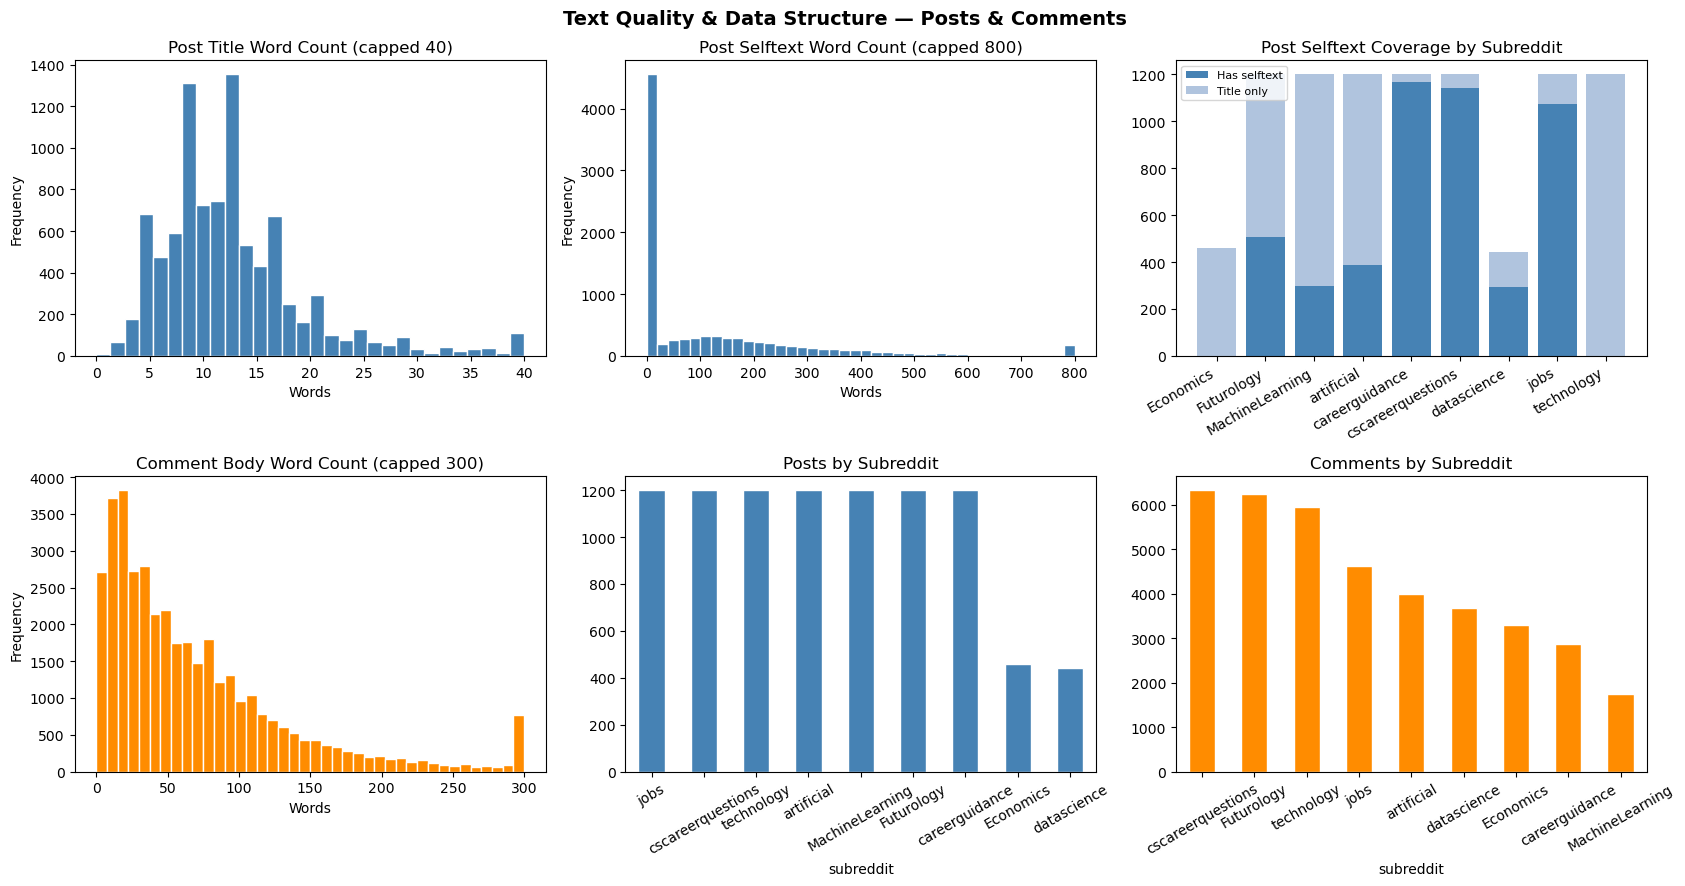

In [11]:

# ── 4. Visualizations ────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Text Quality & Data Structure — Posts & Comments", fontsize=14, fontweight='bold')

# (0,0) Post title word count distribution
posts_clean['title_word_count'].clip(upper=40).plot.hist(
    bins=30, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title("Post Title Word Count (capped 40)")
axes[0,0].set_xlabel("Words")

# (0,1) Post selftext word count
posts_clean['selftext_word_count'].clip(upper=800).plot.hist(
    bins=40, ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title("Post Selftext Word Count (capped 800)")
axes[0,1].set_xlabel("Words")

# (0,2) Selftext coverage by subreddit (stacked bar)
selftext_present = posts_clean.groupby('subreddit')['selftext'].apply(
    lambda x: (x.str.strip() != '').sum())
selftext_absent  = posts_clean.groupby('subreddit')['selftext'].apply(
    lambda x: (x.str.strip() == '').sum())
subs = selftext_present.index.tolist()
x = np.arange(len(subs))
axes[0,2].bar(x, selftext_present.values, label='Has selftext', color='steelblue')
axes[0,2].bar(x, selftext_absent.values,  label='Title only',   color='lightsteelblue',
              bottom=selftext_present.values)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(subs, rotation=30, ha='right')
axes[0,2].set_title("Post Selftext Coverage by Subreddit")
axes[0,2].legend(fontsize=8)

# (1,0) Comment body word count
comments_clean['body_word_count'].clip(upper=300).plot.hist(
    bins=40, ax=axes[1,0], color='darkorange', edgecolor='white')
axes[1,0].set_title("Comment Body Word Count (capped 300)")
axes[1,0].set_xlabel("Words")

# (1,1) Posts by subreddit
posts_clean['subreddit'].value_counts().plot.bar(
    ax=axes[1,1], color='steelblue', edgecolor='white')
axes[1,1].set_title("Posts by Subreddit")
axes[1,1].tick_params(axis='x', rotation=30)

# (1,2) Comments by subreddit — symmetric balance check
comments_clean['subreddit'].value_counts().plot.bar(
    ax=axes[1,2], color='darkorange', edgecolor='white')
axes[1,2].set_title("Comments by Subreddit")
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


TIME ANALYSIS SUMMARY
Posts date range:    2025-01-01 -> 2025-12-31
Comments date range: 2025-01-01 -> 2025-12-31
Total posts: 9,302 | Total comments: 38,677


TIME ANALYSIS SUMMARY
Posts date range:    2025-01-01 -> 2025-12-31
Comments date range: 2025-01-01 -> 2025-12-31
Total posts: 9,302 | Total comments: 38,677


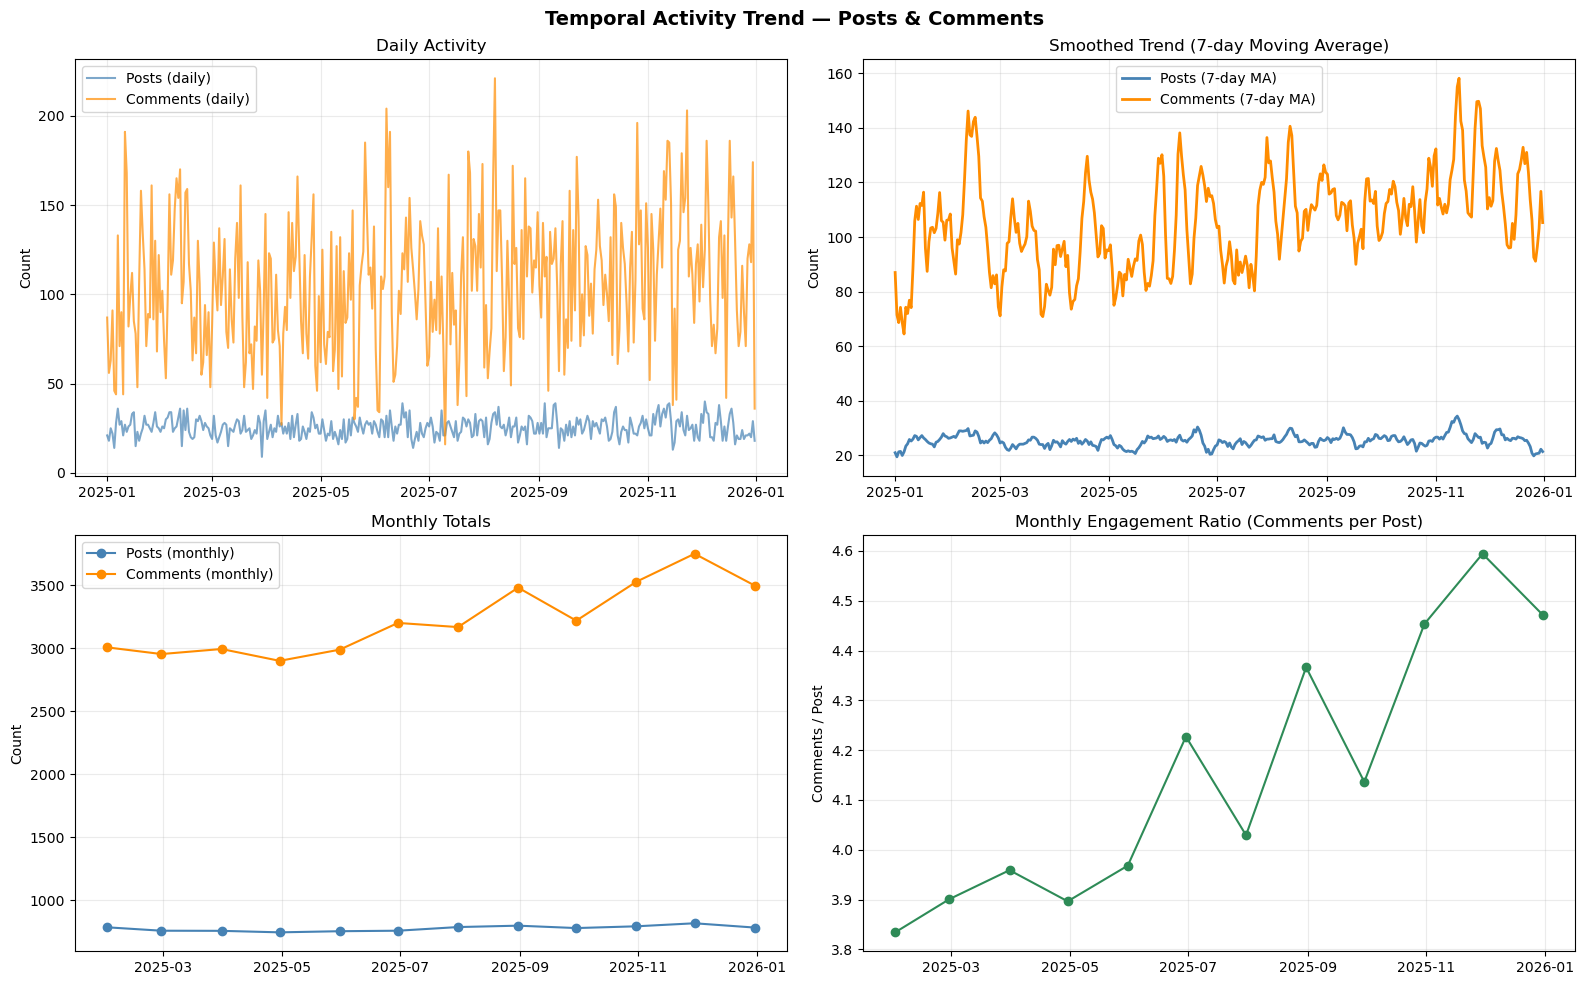

TIME ANALYSIS SUMMARY
Posts date range:    2025-01-01 -> 2025-12-31
Comments date range: 2025-01-01 -> 2025-12-31
Total posts: 9,302 | Total comments: 38,677


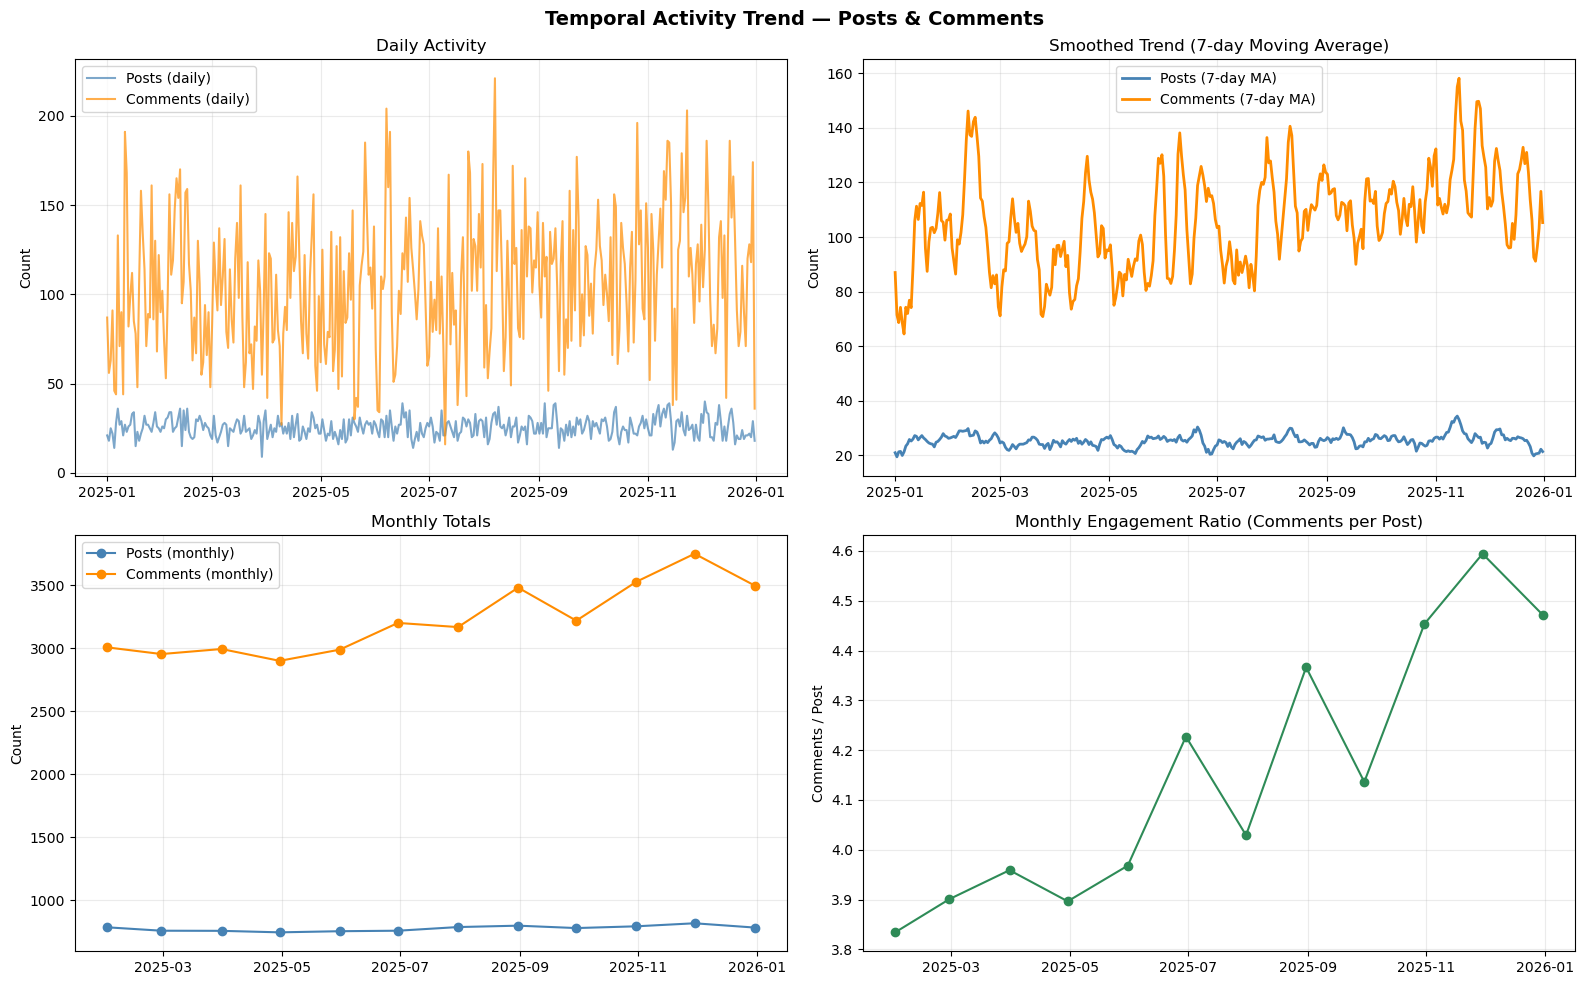

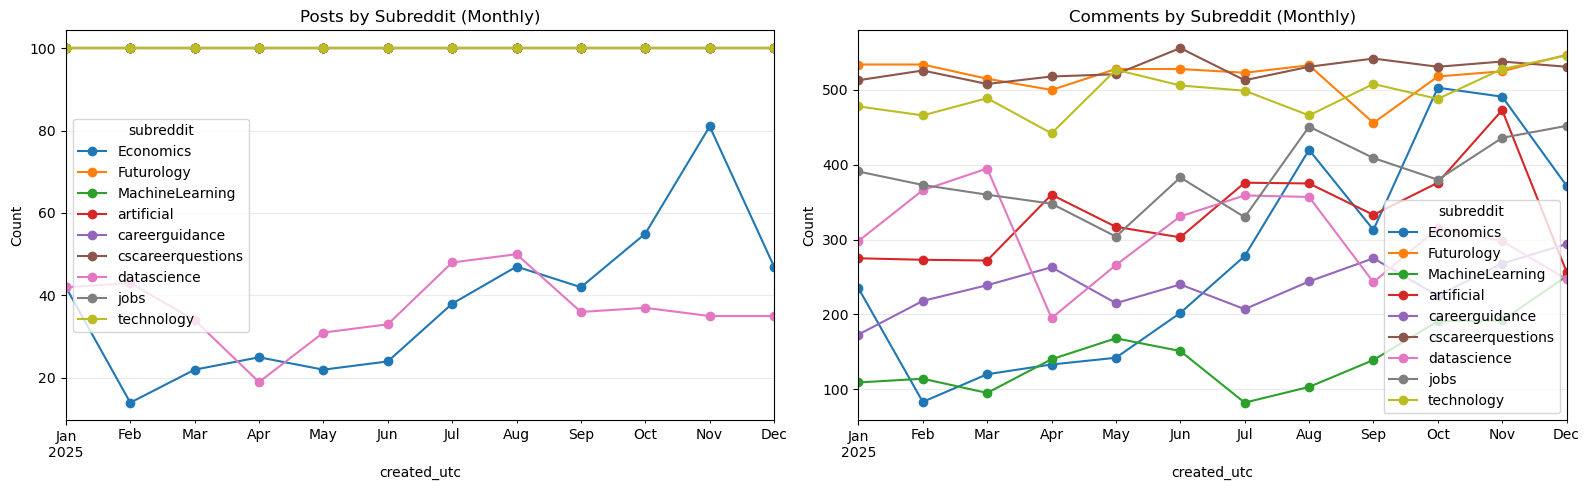

In [12]:
# ── 4b. Time Trend Analysis (Posts vs Comments) ───────────────
# Goal: visualize how posting and commenting activity changes over time.

import matplotlib.pyplot as plt
import pandas as pd

# Prefer cleaned data; fallback to raw data if cleaning cells have not been run yet.
if 'posts_clean' in globals():
    posts_base = posts_clean.copy()
elif 'posts' in globals():
    posts_base = posts.copy()
else:
    raise NameError("posts_clean/posts not found. Please run data loading cells first.")

if 'comments_clean' in globals():
    comments_base = comments_clean.copy()
elif 'comments' in globals():
    comments_base = comments.copy()
else:
    raise NameError("comments_clean/comments not found. Please run data loading cells first.")

# Ensure timestamp column exists
if 'created_utc' not in posts_base.columns or 'created_utc' not in comments_base.columns:
    raise KeyError("created_utc column not found in posts/comments data.")

# Ensure datetime dtype for robust time-series operations
posts_ts = posts_base.copy()
comments_ts = comments_base.copy()
posts_ts['created_utc'] = pd.to_datetime(posts_ts['created_utc'], errors='coerce', unit='s')
comments_ts['created_utc'] = pd.to_datetime(comments_ts['created_utc'], errors='coerce', unit='s')

# If cleaned data already converted to date, second parse above can become NaT; parse again without unit.
posts_ts['created_utc'] = posts_ts['created_utc'].fillna(pd.to_datetime(posts_base['created_utc'], errors='coerce'))
comments_ts['created_utc'] = comments_ts['created_utc'].fillna(pd.to_datetime(comments_base['created_utc'], errors='coerce'))

# Keep valid timestamps only
posts_ts = posts_ts.dropna(subset=['created_utc'])
comments_ts = comments_ts.dropna(subset=['created_utc'])

print('=' * 60)
print('TIME ANALYSIS SUMMARY')
print('=' * 60)
print(f"Posts date range:    {posts_ts['created_utc'].min().date()} -> {posts_ts['created_utc'].max().date()}")
print(f"Comments date range: {comments_ts['created_utc'].min().date()} -> {comments_ts['created_utc'].max().date()}")
print(f"Total posts: {len(posts_ts):,} | Total comments: {len(comments_ts):,}")

# Daily counts
posts_daily = (
    posts_ts
    .set_index('created_utc')
    .resample('D')
    .size()
    .rename('posts')
)
comments_daily = (
    comments_ts
    .set_index('created_utc')
    .resample('D')
    .size()
    .rename('comments')
)

# Align on full shared timeline and fill missing days with 0
timeline = pd.concat([posts_daily, comments_daily], axis=1).fillna(0)

# 7-day rolling average to smooth day-to-day volatility
timeline['posts_7d'] = timeline['posts'].rolling(7, min_periods=1).mean()
timeline['comments_7d'] = timeline['comments'].rolling(7, min_periods=1).mean()

# Monthly totals for macro trend (ME = month end in modern pandas)
monthly = timeline[['posts', 'comments']].resample('ME').sum()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Activity Trend — Posts & Comments', fontsize=14, fontweight='bold')

# (0,0) Daily raw counts
axes[0, 0].plot(timeline.index, timeline['posts'], label='Posts (daily)', color='steelblue', alpha=0.7)
axes[0, 0].plot(timeline.index, timeline['comments'], label='Comments (daily)', color='darkorange', alpha=0.7)
axes[0, 0].set_title('Daily Activity')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

# (0,1) Smoothed trends
axes[0, 1].plot(timeline.index, timeline['posts_7d'], label='Posts (7-day MA)', color='steelblue', linewidth=2)
axes[0, 1].plot(timeline.index, timeline['comments_7d'], label='Comments (7-day MA)', color='darkorange', linewidth=2)
axes[0, 1].set_title('Smoothed Trend (7-day Moving Average)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# (1,0) Monthly totals
axes[1, 0].plot(monthly.index, monthly['posts'], marker='o', label='Posts (monthly)', color='steelblue')
axes[1, 0].plot(monthly.index, monthly['comments'], marker='o', label='Comments (monthly)', color='darkorange')
axes[1, 0].set_title('Monthly Totals')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

# (1,1) Comment/Post ratio by month
ratio = (monthly['comments'] / monthly['posts'].replace(0, pd.NA)).astype('float')
axes[1, 1].plot(monthly.index, ratio, marker='o', color='seagreen')
axes[1, 1].set_title('Monthly Engagement Ratio (Comments per Post)')
axes[1, 1].set_ylabel('Comments / Post')
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Extra: trend by subreddit (monthly), if subreddit exists
if 'subreddit' in posts_ts.columns and 'subreddit' in comments_ts.columns:
    posts_sub_month = (
        posts_ts
        .groupby([pd.Grouper(key='created_utc', freq='ME'), 'subreddit'])
        .size()
        .unstack(fill_value=0)
    )
    comments_sub_month = (
        comments_ts
        .groupby([pd.Grouper(key='created_utc', freq='ME'), 'subreddit'])
        .size()
        .unstack(fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    posts_sub_month.plot(ax=axes[0], marker='o')
    axes[0].set_title('Posts by Subreddit (Monthly)')
    axes[0].set_ylabel('Count')
    axes[0].grid(alpha=0.25)

    comments_sub_month.plot(ax=axes[1], marker='o')
    axes[1].set_title('Comments by Subreddit (Monthly)')
    axes[1].set_ylabel('Count')
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print('No subreddit column found; skipped subreddit monthly trend plots.')

NO-SMOOTHING SAMPLING CONCENTRATION CHECK
Average monthly share captured in first N days:
Posts    - first 3 days: 9.74%, first 5 days: 16.21%, first 7 days: 23.25%
Comments - first 3 days: 8.36%, first 5 days: 14.78%, first 7 days: 21.84%

Monthly concentration table (first 5 days share):
         posts_first5  comments_first5
month                                 
2025-01         0.128            0.114
2025-02         0.193            0.163
2025-03         0.144            0.182
2025-04         0.153            0.149
2025-05         0.154            0.134
2025-06         0.170            0.110
2025-07         0.156            0.135
2025-08         0.143            0.102
2025-09         0.168            0.175
2025-10         0.164            0.169
2025-11         0.156            0.139
2025-12         0.215            0.201


NO-SMOOTHING SAMPLING CONCENTRATION CHECK
Average monthly share captured in first N days:
Posts    - first 3 days: 9.74%, first 5 days: 16.21%, first 7 days: 23.25%
Comments - first 3 days: 8.36%, first 5 days: 14.78%, first 7 days: 21.84%

Monthly concentration table (first 5 days share):
         posts_first5  comments_first5
month                                 
2025-01         0.128            0.114
2025-02         0.193            0.163
2025-03         0.144            0.182
2025-04         0.153            0.149
2025-05         0.154            0.134
2025-06         0.170            0.110
2025-07         0.156            0.135
2025-08         0.143            0.102
2025-09         0.168            0.175
2025-10         0.164            0.169
2025-11         0.156            0.139
2025-12         0.215            0.201


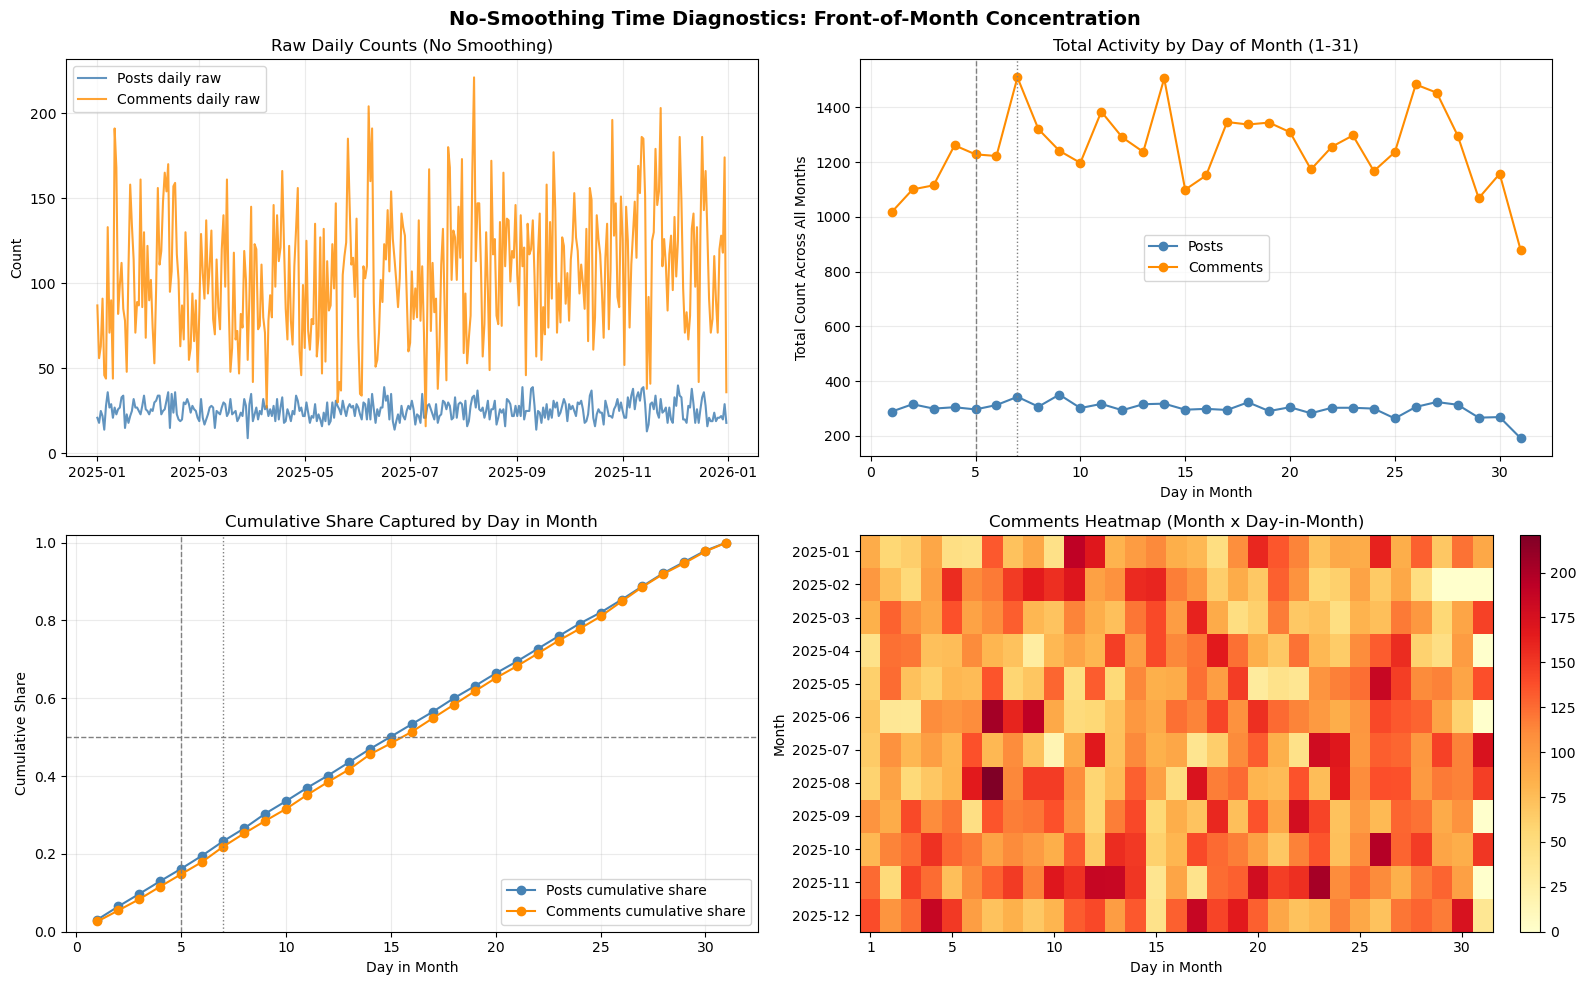

In [13]:
# ── 4c. Sampling Concentration Check (No Smoothing) ───────────
# Purpose: verify whether collection is concentrated in the beginning of each month.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rebuild time-series base robustly (works even if previous cleaning cells were not run)
if 'posts_clean' in globals():
    posts_base2 = posts_clean.copy()
elif 'posts' in globals():
    posts_base2 = posts.copy()
else:
    raise NameError("posts_clean/posts not found. Please run data loading cells first.")

if 'comments_clean' in globals():
    comments_base2 = comments_clean.copy()
elif 'comments' in globals():
    comments_base2 = comments.copy()
else:
    raise NameError("comments_clean/comments not found. Please run data loading cells first.")

posts_raw = posts_base2.copy()
comments_raw = comments_base2.copy()

# Parse timestamp from either unix seconds or date-like string
posts_raw['created_utc'] = pd.to_datetime(posts_raw['created_utc'], errors='coerce', unit='s')
comments_raw['created_utc'] = pd.to_datetime(comments_raw['created_utc'], errors='coerce', unit='s')
posts_raw['created_utc'] = posts_raw['created_utc'].fillna(pd.to_datetime(posts_base2['created_utc'], errors='coerce'))
comments_raw['created_utc'] = comments_raw['created_utc'].fillna(pd.to_datetime(comments_base2['created_utc'], errors='coerce'))

posts_raw = posts_raw.dropna(subset=['created_utc']).copy()
comments_raw = comments_raw.dropna(subset=['created_utc']).copy()

# Feature engineering for concentration diagnostics
for df in [posts_raw, comments_raw]:
    df['month'] = df['created_utc'].dt.to_period('M').astype(str)
    df['day_in_month'] = df['created_utc'].dt.day

# 1) No-smoothing daily counts
posts_daily_raw = posts_raw.set_index('created_utc').resample('D').size()
comments_daily_raw = comments_raw.set_index('created_utc').resample('D').size()

# 2) Average day-of-month profile (1..31)
posts_dom = posts_raw.groupby('day_in_month').size().reindex(range(1, 32), fill_value=0)
comments_dom = comments_raw.groupby('day_in_month').size().reindex(range(1, 32), fill_value=0)

# 3) Month-by-day matrix (for heatmaps)
posts_mx = posts_raw.groupby(['month', 'day_in_month']).size().unstack(fill_value=0).reindex(columns=range(1, 32), fill_value=0)
comments_mx = comments_raw.groupby(['month', 'day_in_month']).size().unstack(fill_value=0).reindex(columns=range(1, 32), fill_value=0)

# 4) Concentration metrics: share in first N days of each month
def first_n_share(month_day_matrix, n):
    total = month_day_matrix.sum(axis=1).replace(0, pd.NA)
    head = month_day_matrix.loc[:, 1:n].sum(axis=1)
    return (head / total).astype('float')

metrics = pd.DataFrame({
    'posts_first3': first_n_share(posts_mx, 3),
    'posts_first5': first_n_share(posts_mx, 5),
    'posts_first7': first_n_share(posts_mx, 7),
    'comments_first3': first_n_share(comments_mx, 3),
    'comments_first5': first_n_share(comments_mx, 5),
    'comments_first7': first_n_share(comments_mx, 7)
})

print('=' * 70)
print('NO-SMOOTHING SAMPLING CONCENTRATION CHECK')
print('=' * 70)
print('Average monthly share captured in first N days:')
print(f"Posts    - first 3 days: {metrics['posts_first3'].mean():.2%}, first 5 days: {metrics['posts_first5'].mean():.2%}, first 7 days: {metrics['posts_first7'].mean():.2%}")
print(f"Comments - first 3 days: {metrics['comments_first3'].mean():.2%}, first 5 days: {metrics['comments_first5'].mean():.2%}, first 7 days: {metrics['comments_first7'].mean():.2%}")
print('\nMonthly concentration table (first 5 days share):')
print(metrics[['posts_first5', 'comments_first5']].round(3).to_string())

# 5) Cumulative day-of-month share curves
posts_dom_share = posts_dom / posts_dom.sum() if posts_dom.sum() > 0 else posts_dom
comments_dom_share = comments_dom / comments_dom.sum() if comments_dom.sum() > 0 else comments_dom
posts_dom_cum = posts_dom_share.cumsum()
comments_dom_cum = comments_dom_share.cumsum()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('No-Smoothing Time Diagnostics: Front-of-Month Concentration', fontsize=14, fontweight='bold')

# (0,0) Raw daily counts (no smoothing)
axes[0, 0].plot(posts_daily_raw.index, posts_daily_raw.values, color='steelblue', alpha=0.85, label='Posts daily raw')
axes[0, 0].plot(comments_daily_raw.index, comments_daily_raw.values, color='darkorange', alpha=0.80, label='Comments daily raw')
axes[0, 0].set_title('Raw Daily Counts (No Smoothing)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

# (0,1) Average count by day-in-month
days = np.arange(1, 32)
axes[0, 1].plot(days, posts_dom.values, marker='o', color='steelblue', label='Posts')
axes[0, 1].plot(days, comments_dom.values, marker='o', color='darkorange', label='Comments')
axes[0, 1].axvline(5, color='gray', linestyle='--', linewidth=1)
axes[0, 1].axvline(7, color='gray', linestyle=':', linewidth=1)
axes[0, 1].set_title('Total Activity by Day of Month (1-31)')
axes[0, 1].set_xlabel('Day in Month')
axes[0, 1].set_ylabel('Total Count Across All Months')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# (1,0) Cumulative share by day-in-month
axes[1, 0].plot(days, posts_dom_cum.values, marker='o', color='steelblue', label='Posts cumulative share')
axes[1, 0].plot(days, comments_dom_cum.values, marker='o', color='darkorange', label='Comments cumulative share')
axes[1, 0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1, 0].axvline(5, color='gray', linestyle='--', linewidth=1)
axes[1, 0].axvline(7, color='gray', linestyle=':', linewidth=1)
axes[1, 0].set_title('Cumulative Share Captured by Day in Month')
axes[1, 0].set_xlabel('Day in Month')
axes[1, 0].set_ylabel('Cumulative Share')
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

# (1,1) Month x day heatmap for comments (often more sensitive to sampling cadence)
im = axes[1, 1].imshow(comments_mx.values, aspect='auto', cmap='YlOrRd')
axes[1, 1].set_title('Comments Heatmap (Month x Day-in-Month)')
axes[1, 1].set_xlabel('Day in Month')
axes[1, 1].set_ylabel('Month')
axes[1, 1].set_xticks([0, 4, 9, 14, 19, 24, 29])
axes[1, 1].set_xticklabels([1, 5, 10, 15, 20, 25, 30])
axes[1, 1].set_yticks(np.arange(len(comments_mx.index)))
axes[1, 1].set_yticklabels(comments_mx.index.tolist())
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Anomaly Investigation

Three dimensions are examined: score distribution, text length, and title duplication. Each anomaly is reviewed in context and a decision is made on whether to remove, keep, or defer to NLP preprocessing.

In [14]:
# ── 5a. Score Analysis ───────────────────────────────────────
print("=" * 60)
print("SCORE ANALYSIS — Posts")
print("=" * 60)

# Low-score posts (score <= 0)
p_low = posts_clean[posts_clean['score'] <= 0]
print(f"Posts with score <= 0:  {len(p_low)}  ({100*len(p_low)/len(posts_clean):.1f}%)")
if len(p_low) > 0:
    print(p_low[['id', 'title', 'score', 'num_comments']].head(5).to_string(index=False))

print()

# High-score posts (99th percentile)
p_score_q99 = posts_clean['score'].quantile(0.99)
p_high = posts_clean[posts_clean['score'] > p_score_q99]
print(f"Posts with score > 99th pct ({p_score_q99:.0f}):  {len(p_high)}  ({100*len(p_high)/len(posts_clean):.1f}%)")
if len(p_high) > 0:
    print(p_high[['id', 'title', 'score', 'num_comments']].head(5).to_string(index=False))

print()
print("=" * 60)
print("SCORE ANALYSIS — Comments")
print("=" * 60)

# Low-score comments (score < 0)
c_low = comments_clean[comments_clean['score'] < 0]
print(f"Comments with score < 0:  {len(c_low)}  ({100*len(c_low)/len(comments_clean):.1f}%)")
if len(c_low) > 0:
    print(c_low[['id', 'body', 'score']].head(5).to_string(index=False))

print()

# High-score comments (99th percentile)
c_score_q99 = comments_clean['score'].quantile(0.99)
c_high = comments_clean[comments_clean['score'] > c_score_q99]
print(f"Comments with score > 99th pct ({c_score_q99:.0f}):  {len(c_high)}  ({100*len(c_high)/len(comments_clean):.1f}%)")
if len(c_high) > 0:
    print(c_high[['id', 'body', 'score']].head(5).to_string(index=False))


SCORE ANALYSIS — Posts
Posts with score <= 0:  1906  (20.5%)
     id                                                                                                        title  score  num_comments
1i8lqvm                                                                    Why is it so hard to get a job right now?      0             1
1i4bfst RANT: Recent grad struggling to find work while previous coworker got promoted to IT position with no degree      0             6
1i8g0ev                                                                                            Future job market      0             1
1hxsxgh                                                                                        Never Gonna Get Hired      0             2
1i8mwri                                                                                   I don't care about resumes      0             2

Posts with score > 99th pct (2966):  94  (1.0%)
     id                                                       

In [15]:
# ── 5b. Body / Selftext Length Analysis ──────────────────────
print("=" * 60)
print("TEXT LENGTH ANALYSIS — Post Selftext")
print("=" * 60)

# Posts with no selftext (title only)
title_only = posts_clean[posts_clean['selftext'].str.strip() == '']
print(f"Posts with no selftext (title only):  {len(title_only)}  ({100*len(title_only)/len(posts_clean):.1f}%)")

# Posts with very short selftext (1–4 words)
short_selftext = posts_clean[
    (posts_clean['selftext'].str.strip() != '') &
    (posts_clean['selftext_word_count'].fillna(0) < 5)
]
print(f"Posts with selftext 1–4 words:        {len(short_selftext)}  ({100*len(short_selftext)/len(posts_clean):.1f}%)")
if len(short_selftext) > 0:
    print(short_selftext[['id', 'title', 'selftext', 'selftext_word_count', 'score']].head(5).to_string(index=False))

print()
print("=" * 60)
print("TEXT LENGTH ANALYSIS — Comment Body")
print("=" * 60)

# Comments with body < 3 words (will be removed)
short_comments = comments_clean[comments_clean['body_word_count'] < 3]
print(f"Comments with body < 3 words:  {len(short_comments)}  ({100*len(short_comments)/len(comments_clean):.1f}%)  ← will be removed")
if len(short_comments) > 0:
    print(short_comments[['id', 'body', 'score']].head(10).to_string(index=False))

print()

# Comments with body 3–10 words (borderline, informational)
borderline = comments_clean[
    (comments_clean['body_word_count'] >= 3) &
    (comments_clean['body_word_count'] <= 10)
]
print(f"Comments with body 3–10 words: {len(borderline)}  ({100*len(borderline)/len(comments_clean):.1f}%)  ← kept")
if len(borderline) > 0:
    print(borderline[['id', 'body', 'score']].head(5).to_string(index=False))


TEXT LENGTH ANALYSIS — Post Selftext
Posts with no selftext (title only):  4433  (47.7%)
Posts with selftext 1–4 words:        22  (0.2%)
     id                                                                                                                                                                  title          selftext  selftext_word_count  score
1i6ld1p                                                                                                                               Who is more intelligent: you or your AI?            Title.                    1      0
1ig4b0b                                                                                                                          Which new AI model is the best, in your view? removed View Poll                    3      1
1j2cry6 The old dating trope of testing someone on if they are a good person on whether or not they return the grocery cart... I think the new one is if you are polite to AI.            Title.       

In [16]:
# ── 5c. Title Analysis ───────────────────────────────────────
print("=" * 60)
print("TITLE ANALYSIS — Duplicate Titles")
print("=" * 60)

# Cross-subreddit duplicates (same title, different subreddit) → KEPT
# These represent the same topic discussed independently in different communities
cross_sub_dup = posts_clean[
    posts_clean.duplicated(subset=['title'], keep=False) &
    ~posts_clean.duplicated(subset=['title', 'subreddit'], keep=False)
]
print(f"Same title, different subreddit: {len(cross_sub_dup)} rows  ← KEPT (independent community discussions)")
if len(cross_sub_dup) > 0:
    print(cross_sub_dup[['id', 'title', 'subreddit', 'score']].sort_values('title').head(8).to_string(index=False))

print()

# Within-subreddit duplicates (same title AND same subreddit) → DEDUPLICATE in Step 6
within_sub_dup = posts_clean[posts_clean.duplicated(subset=['title', 'subreddit'], keep=False)]
print(f"Same title, same subreddit:      {len(within_sub_dup)} rows  ← will keep highest-score copy per (title, subreddit)")
if len(within_sub_dup) > 0:
    print(within_sub_dup[['id', 'title', 'subreddit', 'score']].sort_values(['title', 'subreddit']).head(8).to_string(index=False))

print()
print("=" * 60)
print("TITLE ANALYSIS — Short Titles")
print("=" * 60)

short_titles = posts_clean[posts_clean['title_word_count'] < 4]
print(f"Posts with title < 4 words:  {len(short_titles)}  ({100*len(short_titles)/len(posts_clean):.1f}%)  ← kept")
if len(short_titles) > 0:
    print(short_titles[['id', 'title', 'title_word_count', 'score']].head(10).to_string(index=False))


TITLE ANALYSIS — Duplicate Titles
Same title, different subreddit: 190 rows  ← KEPT (independent community discussions)
     id                                                                          title         subreddit  score
1kp56aj                                                                                  MachineLearning      1
1kjc3e7                                                                                cscareerquestions      1
1n4mfyh 'AI can t install an HVAC system': Why Gen Z is flocking to jobs in the trades         Economics    872
1n4q77v 'AI can t install an HVAC system': Why Gen Z is flocking to jobs in the trades        technology   4027
1n4q7f7 'AI can t install an HVAC system': Why Gen Z is flocking to jobs in the trades              jobs   1336
1hx5cg9          41 of companies worldwide plan to reduce workforces by 2030 due to AI        Futurology     13
1ntcqmp                                                                             AI        ar

### Decision Summary

Decisions are based on the research context of *public sentiment on AI and its impact on the job market*.

---

**5a — Score Analysis (Posts & Comments)**

| Anomaly | Decision | Reasoning |
|---|---|---|
| Posts with score ≤ 0 | ✅ Kept | Low or zero scores may reflect unpopular opinions, but these still carry genuine sentiment. Removing them would introduce survivorship bias. |
| Comments with score < 0 | ✅ Kept | Downvoted comments often express minority or controversial views — still valuable for capturing the full sentiment spectrum. |
| High-score posts/comments (> 99th pct) | ✅ Kept | High scores reflect community agreement and wide engagement — the most representative sentiment signals. |

---

**5b — Body / Selftext Length Analysis**

| Anomaly | Decision | Reasoning |
|---|---|---|
| Posts with no selftext (title only) | ✅ Kept | Title alone expresses clear sentiment (e.g. *"AI just took my job"*). `full_text` falls back to title when selftext is absent. |
| Posts with selftext 1–4 words | ✅ Kept | Short body text does not imply low sentiment value in this context. |
| Comments with body < 3 words | ❌ Removed in NLP Preprocessing | Responses like *"lol"*, *"this"*, *"agreed"* contain no analysable content and add pure noise. |

---

**5c — Title Analysis**

| Scenario | Decision | Reasoning |
|---|---|---|
| Same title, **different** subreddit | ✅ Kept | The same topic trending across multiple communities reflects independent discussions with distinct perspectives. Keeping both is essential for cross-community sentiment comparison. |
| Same title, **same** subreddit | ❌ Deduplicated in NLP Preprocessing | Same post collected across monthly API windows. The copy with the **highest score** is retained. |
| Short titles (< 4 words) | ✅ Kept | Short titles are valid and often expressive (e.g. *"AI replaced me"*). |

# NLP Preprocessing

Based on the anomaly investigation above, the following operations are applied to produce the final NLP-ready dataset:

1. **Remove short comments** (`body_word_count < 3`) — eliminates noise with no sentiment value.
2. **Deduplicate posts** by `(title, subreddit)` — keep the highest-scoring copy to avoid double-counting across monthly API windows.
3. **Construct `full_text`** — combines `title` + `selftext` when both are present; falls back to `title` alone when `selftext` is absent. Ensures all 9 subreddits are retained.
4. **Retain `word_count` features** — `title_word_count`, `selftext_word_count`, `body_word_count` are kept as NLP-ready variables.

In [17]:
# ── Step 6 — Data Preparation Actions ────────────────────────

# 6a. Remove short comments (body < 3 words = noise with no sentiment value)
before = len(comments_clean)
comments_clean = comments_clean[comments_clean['body_word_count'] >= 3].copy()
print(f"Removed short comments (<3 words): {before - len(comments_clean)}  →  {len(comments_clean)} comments remaining")

# 6b. Deduplicate posts by (title + subreddit) — keep highest-score copy
#     Same title in DIFFERENT subreddits: KEPT (independent community discussions)
#     Same title in SAME subreddit:       DEDUPLICATED (same post collected across monthly windows)
before = len(posts_clean)
posts_clean = (
    posts_clean
    .sort_values('score', ascending=False)
    .drop_duplicates(subset=['title', 'subreddit'], keep='first')
    .copy()
)
print(f"Deduplicated posts (same title+subreddit): {before - len(posts_clean)} removed  →  {len(posts_clean)} posts remaining")

# 6c. full_text: title + selftext when available, title only when selftext is empty
posts_clean['full_text'] = posts_clean.apply(
    lambda r: (r['title'] + " " + r['selftext']).strip() if str(r['selftext']).strip() else r['title'],
    axis=1
)
has_both   = posts_clean['selftext'].str.strip().ne('').sum()
title_only = posts_clean['selftext'].str.strip().eq('').sum()
print(f"full_text source — title+selftext: {has_both}, title only: {title_only}")

# 6d. word_count columns (title_word_count, selftext_word_count, body_word_count) are retained
#     as NLP-ready features — no temporary columns remain to drop at this stage.

# 6e. Reset index so final DataFrames have clean 0-based sequential index
posts_clean    = posts_clean.reset_index(drop=True)
comments_clean = comments_clean.reset_index(drop=True)

# 6f. Final state
print(f"\nFinal posts shape:    {posts_clean.shape}")
print(f"Final comments shape: {comments_clean.shape}")
print(f"\nPosts columns:    {posts_clean.columns.tolist()}")
print(f"Comments columns: {comments_clean.columns.tolist()}")
print(f"\nSubreddits in posts:    {sorted(posts_clean['subreddit'].unique())}")
print(f"Subreddits in comments: {sorted(comments_clean['subreddit'].unique())}")



Removed short comments (<3 words): 551  →  38126 comments remaining
Deduplicated posts (same title+subreddit): 85 removed  →  9217 posts remaining
full_text source — title+selftext: 4841, title only: 4376

Final posts shape:    (9217, 10)
Final comments shape: (38126, 7)

Posts columns:    ['created_utc', 'id', 'num_comments', 'score', 'selftext', 'subreddit', 'title', 'title_word_count', 'selftext_word_count', 'full_text']
Comments columns: ['body', 'created_utc', 'id', 'link_id', 'score', 'subreddit', 'body_word_count']

Subreddits in posts:    ['Economics', 'Futurology', 'MachineLearning', 'artificial', 'careerguidance', 'cscareerquestions', 'datascience', 'jobs', 'technology']
Subreddits in comments: ['Economics', 'Futurology', 'MachineLearning', 'artificial', 'careerguidance', 'cscareerquestions', 'datascience', 'jobs', 'technology']


# Export

Final datasets are saved as CSV . A verification cell confirms shape, date range, subreddit coverage, and null counts of both files.

In [18]:

# ── Export Final Cleaned Datasets ────────────────────────────
import os

OUTPUT_DIR = r"c:\Users\13515\Downloads\ML_project\cleandata"

posts_out    = os.path.join(OUTPUT_DIR, "reddit_posts_clean.csv")
comments_out = os.path.join(OUTPUT_DIR, "reddit_comments_clean.csv")

# Fill empty text columns so CSV round-trip doesn't introduce NaN
for col in ['title', 'selftext', 'full_text']:
    posts_clean[col] = posts_clean[col].fillna('')

# Drop the rare post where title/full_text is empty after cleaning (regex stripped all content)
before = len(posts_clean)
posts_clean = posts_clean[posts_clean['title'].str.strip() != '']
posts_clean = posts_clean[posts_clean['full_text'].str.strip() != '']
print(f"Dropped {before - len(posts_clean)} post(s) with empty title/full_text after text cleaning")

posts_clean.to_csv(posts_out,    index=False)
comments_clean.to_csv(comments_out, index=False)

print(f" Posts saved:    {posts_out}  ({len(posts_clean):,} rows)")
print(f" Comments saved: {comments_out}  ({len(comments_clean):,} rows)")


Dropped 2 post(s) with empty title/full_text after text cleaning
 Posts saved:    c:\Users\13515\Downloads\ML_project\cleandata\reddit_posts_clean.csv  (9,215 rows)
 Comments saved: c:\Users\13515\Downloads\ML_project\cleandata\reddit_comments_clean.csv  (38,126 rows)


In [19]:

# ── Verify Exported CSVs ──────────────────────────────────────
import pandas as pd
import os

OUTPUT_DIR = r"c:\Users\13515\Downloads\ML_project\cleandata"
posts_out    = os.path.join(OUTPUT_DIR, "reddit_posts_clean.csv")
comments_out = os.path.join(OUTPUT_DIR, "reddit_comments_clean.csv")

p = pd.read_csv(posts_out,    parse_dates=['created_utc'])
c = pd.read_csv(comments_out, parse_dates=['created_utc'])

# Empty string text columns are round-tripped as NaN by pandas CSV — restore them
for col in ['title', 'selftext', 'full_text']:
    p[col] = p[col].fillna('')

print("=" * 60)
print("reddit_posts_clean.csv")
print("=" * 60)
print(f"Shape:       {p.shape}")
print(f"Columns:     {p.columns.tolist()}")
print(f"Date range:  {p['created_utc'].min().date()}  →  {p['created_utc'].max().date()}")
print(f"Subreddits:  {sorted(p['subreddit'].unique())}")
print(f"Null counts:\n{p.isnull().sum()}")

print()
print("=" * 60)
print("reddit_comments_clean.csv")
print("=" * 60)
print(f"Shape:       {c.shape}")
print(f"Columns:     {c.columns.tolist()}")
print(f"Date range:  {c['created_utc'].min().date()}  →  {c['created_utc'].max().date()}")
print(f"Subreddits:  {sorted(c['subreddit'].unique())}")
print(f"Null counts:\n{c.isnull().sum()}")


reddit_posts_clean.csv
Shape:       (9215, 10)
Columns:     ['created_utc', 'id', 'num_comments', 'score', 'selftext', 'subreddit', 'title', 'title_word_count', 'selftext_word_count', 'full_text']
Date range:  2025-01-01  →  2025-12-31
Subreddits:  ['Economics', 'Futurology', 'MachineLearning', 'artificial', 'careerguidance', 'cscareerquestions', 'datascience', 'jobs', 'technology']
Null counts:
created_utc            0
id                     0
num_comments           0
score                  0
selftext               0
subreddit              0
title                  0
title_word_count       0
selftext_word_count    0
full_text              0
dtype: int64

reddit_comments_clean.csv
Shape:       (38126, 7)
Columns:     ['body', 'created_utc', 'id', 'link_id', 'score', 'subreddit', 'body_word_count']
Date range:  2025-01-01  →  2025-12-31
Subreddits:  ['Economics', 'Futurology', 'MachineLearning', 'artificial', 'careerguidance', 'cscareerquestions', 'datascience', 'jobs', 'technology']
Nul

In [20]:
print(comments_clean.info())
print(posts_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38126 entries, 0 to 38125
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   body             38126 non-null  object
 1   created_utc      38126 non-null  object
 2   id               38126 non-null  object
 3   link_id          38126 non-null  object
 4   score            38126 non-null  int64 
 5   subreddit        38126 non-null  object
 6   body_word_count  38126 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.0+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 9215 entries, 0 to 9216
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   created_utc          9215 non-null   object
 1   id                   9215 non-null   object
 2   num_comments         9215 non-null   int64 
 3   score                9215 non-null   int64 
 4   selftext             9215 non-n

In [21]:
# Numeric feature statistics for final cleaned datasets

print("Numeric Data Statistics — Posts (posts_clean)")
print(posts_clean.describe().round(2))

print()

print("Numeric Data Statistics — Comments (comments_clean)")
print(comments_clean.describe().round(2))


Numeric Data Statistics — Posts (posts_clean)
       num_comments     score  title_word_count  selftext_word_count
count       9215.00   9215.00           9215.00              9215.00
mean          26.16    160.26             12.60               134.27
std          123.14   1507.71              7.13               240.82
min            0.00      0.00              1.00                 0.00
25%            0.00      1.00              8.00                 0.00
50%            2.00      1.00             11.00                31.00
75%           11.00      6.00             15.00               197.00
max         4813.00  78147.00             61.00              4802.00

Numeric Data Statistics — Comments (comments_clean)
          score  body_word_count
count  38126.00         38126.00
mean      45.57            72.75
std      316.32            79.65
min     -432.00             3.00
25%        1.00            22.00
50%        4.00            51.00
75%       19.00            95.00
max    25076.00 

## 4d. Quick Validation: Original vs New Sampling Strategy

Compare day-of-month distribution to verify bias reduction from the new 4-segment asc+desc strategy.

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ========== Load Original Data ==========
original_posts_path = r"c:\Users\13515\Downloads\ML_project\chunks\merged_posts.csv"
original_data = pd.read_csv(original_posts_path)
original_data['_dt'] = pd.to_datetime(original_data['created_utc'], unit='s', utc=True)
original_data['_day_of_month'] = original_data['_dt'].dt.day

print(f"✓ Original posts: {len(original_data)} records")
print(f"  Date range: {original_data['_dt'].min()} → {original_data['_dt'].max()}")

# ========== Load New Test Data ==========
# Try bimonthly label: 2025-01 → 2025-01_2025-02
test_posts_path = r"c:\Users\13515\Downloads\ML_project\reddit_data_Q2\posts_Q2_full.csv"

if os.path.exists(test_posts_path):
    new_data = pd.read_csv(test_posts_path)
    new_data['_dt'] = pd.to_datetime(new_data['created_utc'], unit='s', utc=True)
    new_data['_day_of_month'] = new_data['_dt'].dt.day
    print(f"\n✓ New test posts: {len(new_data)} records")
    print(f"  Date range: {new_data['_dt'].min()} → {new_data['_dt'].max()}")
    has_new_data = True
else:
    print(f"\n⚠ Test data not found at: {test_posts_path}")
    print("  (No problem—create it by running Fetchdata_code.ipynb Cells 1-10)")
    has_new_data = False

# ========== Day-of-Month Analysis ==========
def compute_day_stats(df, name):
    """Compute first-N-days concentration metrics."""
    counts = df['_day_of_month'].value_counts().sort_index()
    total = counts.sum()
    
    first_5_days = counts.loc[counts.index <= 5].sum()
    first_5_pct = (first_5_days / total * 100) if total > 0 else 0.0
    
    first_10_days = counts.loc[counts.index <= 10].sum()
    first_10_pct = (first_10_days / total * 100) if total > 0 else 0.0
    
    print(f"\n{name}:")
    print(f"  Total posts: {total}")
    print(f"  First 5 days:  {first_5_days:4d} posts ({first_5_pct:.1f}%)")
    print(f"  First 10 days: {first_10_days:4d} posts ({first_10_pct:.1f}%)")
    
    return {
        'first_5_days': first_5_days,
        'first_5_pct': first_5_pct,
        'first_10_days': first_10_days,
        'first_10_pct': first_10_pct,
        'counts': counts
    }

original_stats = compute_day_stats(original_data, "Original Data (all months)")
if has_new_data:
    new_stats = compute_day_stats(new_data, "New Test Data (2025-01 with new strategy)")
    improvement_5 = original_stats['first_5_pct'] - new_stats['first_5_pct']
    improvement_10 = original_stats['first_10_pct'] - new_stats['first_10_pct']
    print(f"\n📊 Improvement:")
    print(f"  First 5 days:  {improvement_5:+.1f}% (lower is better)")
    print(f"  First 10 days: {improvement_10:+.1f}% (lower is better)")
    if improvement_5 > 10:
        print(f"  ✅ Bias reduction SIGNIFICANT (~{improvement_5:.0f}% improvement)")
    elif improvement_5 > 0:
        print(f"  ⚠️  Bias reduction modest (~{improvement_5:.0f}% improvement—may need more testing)")
    else:
        print(f"  ❌ No improvement detected—check sampling strategy")

✓ Original posts: 9931 records
  Date range: 2025-01-01 00:16:16+00:00 → 2025-12-31 10:17:04+00:00

✓ New test posts: 2254 records
  Date range: 2025-04-01 00:00:43+00:00 → 2025-06-30 23:07:28+00:00

Original Data (all months):
  Total posts: 9931
  First 5 days:  4719 posts (47.5%)
  First 10 days: 6171 posts (62.1%)

New Test Data (2025-01 with new strategy):
  Total posts: 2254
  First 5 days:   359 posts (15.9%)
  First 10 days:  735 posts (32.6%)

📊 Improvement:
  First 5 days:  +31.6% (lower is better)
  First 10 days: +29.5% (lower is better)
  ✅ Bias reduction SIGNIFICANT (~32% improvement)


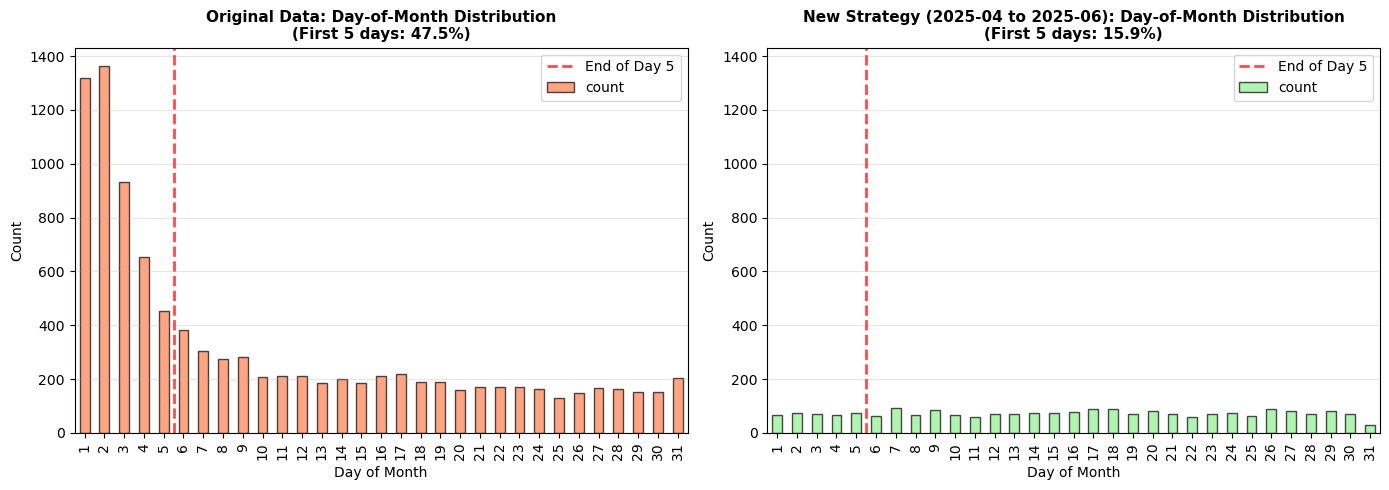


📈 Interpretation:
  ✅ New strategy REDUCED first-5-days concentration from 47.5% to 15.9%
  → This validates the asc+desc 4-segment approach is working!


In [23]:
# ========== Visualization ==========
if has_new_data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Original Data
    ax1 = axes[0]
    original_stats['counts'].plot(kind='bar', ax=ax1, color='coral', alpha=0.7, edgecolor='black')
    ax1.set_title(f"Original Data: Day-of-Month Distribution\n(First 5 days: {original_stats['first_5_pct']:.1f}%)", fontsize=11, fontweight='bold')
    ax1.set_xlabel("Day of Month")
    ax1.set_ylabel("Count")
    ax1.grid(axis='y', alpha=0.3)
    ax1.axvline(x=4.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='End of Day 5')
    ax1.legend()
    
    # Plot 2: New Test Data
    ax2 = axes[1]
    new_stats['counts'].plot(kind='bar', ax=ax2, color='lightgreen', alpha=0.7, edgecolor='black')
    ax2.set_title(f"New Strategy (2025-04 to 2025-06): Day-of-Month Distribution\n(First 5 days: {new_stats['first_5_pct']:.1f}%)", fontsize=11, fontweight='bold')
    ax2.set_xlabel("Day of Month")
    ax2.set_ylabel("Count")
    ax2.grid(axis='y', alpha=0.3)
    ax2.axvline(x=4.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='End of Day 5')
    ax2.legend()
    
    # Align y-axes for easier comparison
    max_y = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(0, max_y)
    ax2.set_ylim(0, max_y)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📈 Interpretation:")
    if new_stats['first_5_pct'] < original_stats['first_5_pct']:
        print(f"  ✅ New strategy REDUCED first-5-days concentration from {original_stats['first_5_pct']:.1f}% to {new_stats['first_5_pct']:.1f}%")
        print(f"  → This validates the asc+desc 4-segment approach is working!")
    else:
        print(f"  ❌ New strategy did NOT reduce bias—first-5-days still {new_stats['first_5_pct']:.1f}%")
        print(f"  → Consider debugging fetch_posts_bucket or expanding test scope")
else:
    print("\n⏭️  Waiting for test data generation...")
    print("   Run Fetchdata_code.ipynb Cells 1-10 to generate: posts_Q2_full.csv")
    print("   Then re-run this cell to see comparison.")